# Memory Forensic Workflow
**Description**

This notebook presents an automated workflow for analyzing Windows memory images as part of a memory forensics investigation. The workflow begins by specifying the path to a Windows memory image that will be analyzed. A memory image represents a snapshot of the system’s volatile memory (RAM) captured at a specific point in time.

Once the memory image path is provided, the framework initiates an automated forensic analysis process using the Volatility memory forensics framework. The workflow extracts and analyzes key forensic artifacts to assist investigators in identifying suspicious or malicious activity within the system.

Memory images can contain valuable forensic evidence, including information about running processes, network connections, loaded drivers, injected code segments, and other system artifacts. Analyzing these artifacts enables investigators to detect indicators of compromise and better understand the behavior of potential malware or unauthorized activities present in the system.

Author:
Bhathiya Madanayaka
bathiyapulasthi@gmail.com

### <a href=#EnvironmentSetup>Environment Setup</a>

Before running the workflow, the required Python packages must be installed. These packages provide the necessary functionality for data processing, security analysis, and visualization within the notebook. 

Please note that **msticpy requires Python version 3.8 or later**. Ensure that the Python environment being used meets this requirement before installing the dependencies.

In [1]:
%pip install msticpy[azure] seaborn jellyfish pandas argparse colorama selenium pillow

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install argparse

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install seaborn matplotlib selenium pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Required Libraries
This section imports the Python libraries required for the automated memory forensic workflow. These libraries support data processing, artifact analysis, threat intelligence extraction, and result visualization within the notebook environment.

In [4]:
# Standard Python libraries
import sys
import os
import re
import argparse

# Data processing
import pandas as pd

# Security and analysis libraries
import jellyfish
import msticpy as mp
from msticpy.transform.iocextract import IoCExtract

# Output formatting
from colorama import init, Fore, Back, Style
from IPython.display import display, HTML

# Expand notebook cell width for better visualization
display(HTML("<style>.container { width:90% !important; }</style>"))

# Initialize MSTICPy
mp.init_notebook(verbosity=0)

# Configure pandas display settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Configuring MSTICPY for Threat Intelligence Lookups
<b>Ensure that the msticpyconfig.yaml file is present in the same directory as this notebook and contains your API keys and credentials for threat intelligence providers.

Once configured, you can initialize the intelligence lookup engine with:</b>

In [5]:
intel = mp.TILookup()


### Specifying Memory Image Path

Eg: !python "path_to_vol.py" -f "path_to/memdump.mem" windows.info

windows.info is a Volatility 3 plugin that collects general system info from the memory image.

It outputs details like kernel base, DTB, processor info, system time, Windows version, and memory layout.

It confirms the memory image is loaded successfully and the framework can access the OS structures.

In [6]:
!python "D:/MSC/MSC research/coding/v2 2026-03-14/volatility3-develop/volatility3-develop/vol.py" -f "D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/MemoryFile/memdump.mem" windows.info



Volatility 3 Framework 2.26.2

Variable	Value

Kernel Base	0x8183a000
DTB	0x122000
Symbols	file:///D:/MSC/MSC%20research/coding/v2%202026-03-14/volatility3-develop/volatility3-develop/volatility3/symbols/windows/ntkrpamp.pdb/37D328E3BAE5460F8E662756ED80951D-2.json.xz
Is64Bit	False
IsPAE	True
layer_name	0 WindowsIntelPAE
memory_layer	1 FileLayer
KdDebuggerDataBlock	0x81931c90
NTBuildLab	6001.18000.x86fre.longhorn_rtm.0
CSDVersion	1
KdVersionBlock	0x81931c68
Major/Minor	15.6001
MachineType	332
KeNumberProcessors	3405774849
SystemTime	2014-01-08 17:54:20+00:00
NtSystemRoot	C:\Windows
NtProductType	NtProductServer
NtMajorVersion	6
NtMinorVersion	0
PE MajorOperatingSystemVersion	6
PE MinorOperatingSystemVersion	0
PE Machine	332
PE TimeDateStamp	Sat Jan 19 05:30:58 2008



Progress:    0.00		Scanning FileLayer using PageMapScanner

Progress:   23.33		Scanning FileLayer using PageMapScanner

Progress:    0.00		Scanning FileLayer using PageMapScanner

Progress:  100.00		Stacking attempts finished             

Progress:    0.00		Scanning memory_layer using BytesScanner

Progress:    3.13		Scanning memory_layer using BytesScanner

Progress:    0.00		Scanning layer_name using PdbSignatureScanner

Progress:    0.00		Scanning layer_name using PdbSignatureScanner

Progress:  100.00		PDB scanning finished                        


### Process Artifact Extraction Using Volatility 3

Purpose:
The PsList plugin in Volatility 3 is used to extract a snapshot of all running processes from a Windows memory image. This provides critical forensic information including process IDs (PID), parent process IDs (PPID), thread counts, handles, session IDs, and creation/termination times. These artifacts form the foundation for subsequent behavioral and anomaly analysis.

Explanation:

-f "memdump.mem": Specifies the path to the memory image.

-r csv: Exports the output in CSV format for easy integration with analysis tools like <b>Pandas</b>.

windows.pslist.PsList: Plugin that lists all running processes in the memory image.

In [7]:
!python "D:/MSC/MSC research/coding/v2 2026-03-14/volatility3-develop/volatility3-develop/vol.py" -f "D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/MemoryFile/memdump.mem" -r csv windows.pslist.PsList


TreeDepth,PID,PPID,ImageFileName,Offset(V),Threads,Handles,SessionId,Wow64,CreateTime,ExitTime,File output
0,4,0,System,0x82db0910,100,541,N/A,False,2014-01-08 02:17:35.000000 UTC,N/A,Disabled
0,404,4,smss.exe,0x8454c118,4,28,N/A,False,2014-01-08 02:17:35.000000 UTC,N/A,Disabled
0,472,460,csrss.exe,0x84561968,11,466,0,False,2014-01-08 02:17:35.000000 UTC,N/A,Disabled
0,516,508,csrss.exe,0x84450770,10,305,1,False,2014-01-08 02:17:36.000000 UTC,N/A,Disabled
0,524,460,wininit.exe,0x84453770,3,98,0,False,2014-01-08 02:17:36.000000 UTC,N/A,Disabled
0,552,508,winlogon.exe,0x84465770,3,116,1,False,2014-01-08 02:17:36.000000 UTC,N/A,Disabled
0,604,524,services.exe,0x83632170,6,250,0,False,2014-01-08 02:17:36.000000 UTC,N/A,Disabled
0,616,524,lsass.exe,0x844bf770,13,610,0,False,2014-01-08 02:17:36.000000 UTC,N/A,Disabled
0,624,524,lsm.exe,0x844c2680,10,208,0,False,2014-01-08 02:17:36.000000 UTC,N/A,Disabled
0,788,604,svchost.exe,0x84866d50,6,298,0,False,2014-01-08 02:17:42.000000 UTC,N/A,Disabl

Volatility 3 Framework 2.26.2

Progress:    0.00		Scanning FileLayer using PageMapScanner

Progress:   23.33		Scanning FileLayer using PageMapScanner

Progress:    0.00		Scanning FileLayer using PageMapScanner

Progress:  100.00		Stacking attempts finished             

Progress:    0.00		Scanning memory_layer using BytesScanner

Progress:    3.13		Scanning memory_layer using BytesScanner

Progress:    0.00		Scanning layer_name using PdbSignatureScanner

Progress:    0.00		Scanning layer_name using PdbSignatureScanner

Progress:  100.00		PDB scanning finished                        


### <a href=#generatecsvs>Generating Required CSVs</a>
#### Purpose:
This step generates the CSV files containing extracted memory artifacts, which are required for subsequent analysis in this notebook. If you already have the CSVs, this step can be skipped.

#### Notes:

Generating CSVs from the memory image can be time-consuming depending on the size of the memory dump.

While the process is running in Jupyter Notebook, a * will appear in the square brackets next to the cell. Wait until the number inside the brackets appears, indicating that the process has completed.

#### Key Points:

Each CSV corresponds to a specific Volatility plugin output (e.g., processes, DLLs, network connections).

These structured CSVs allow the framework to perform data preprocessing, enrichment, and anomaly detection efficiently.

Once CSVs are generated, they can be loaded into Pandas for analysis without re-running Volatility, saving time for repeated tests.

In [8]:
import subprocess
import os
import pandas as pd

# Input/output paths
mem_inpath = "D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/MemoryFile/memdump.mem"
mem_outpath = "D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/"
vol_path = "D:/MSC/MSC research/coding/v2 2026-03-14/volatility3-develop/volatility3-develop/vol.py"

volplug_lst = [
    "windows.pslist.PsList",
    "windows.cmdline.CmdLine",
    "windows.netscan.NetScan",
    "windows.callbacks.Callbacks",
    "windows.driverscan.DriverScan",
    "windows.dlllist.DllList",
    "windows.svcscan.SvcScan",
    "windows.handles.Handles",
    "windows.malfind.Malfind",
    "windows.ssdt.SSDT"
]

# Ensure the output directory exists
os.makedirs(mem_outpath, exist_ok=True)

def clean_and_save_csv(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Find the header line index
    start_index = 0
    for i, line in enumerate(lines):
        if any(x in line for x in ["TreeDepth", "PID"]):
            start_index = i
            break

    try:
        df = pd.read_csv(
            file_path,
            skiprows=start_index,
            header=0,
            engine='python',
            quotechar='"',
            skipinitialspace=True
        )
    except Exception as e:
        print(f"❌ Failed to clean {file_path} → {e}")
        return

    df.columns = df.columns.str.strip()

    base, ext = os.path.splitext(file_path)
    new_path = base + "_updated" + ext
    df.to_csv(new_path, index=False)
    print(f"✅ Cleaned and saved: {new_path}")

    # Remove original CSV file
    try:
        os.remove(file_path)
        print(f"🗑️ Deleted original file: {file_path}")
    except Exception as e:
        print(f"⚠️ Failed to delete {file_path} → {e}")

# Run plugins and clean output
for plugin in volplug_lst:
    output_file = os.path.join(mem_outpath, f"{plugin}.csv")

    cmd = [
        "python", vol_path,
        "-f", mem_inpath,
        "-r", "csv",
        plugin
    ]

    print(f"▶ Running plugin: {plugin}")
    with open(output_file, "w", encoding="utf-8") as outfile:
        subprocess.run(cmd, stdout=outfile, stderr=subprocess.STDOUT, text=True)

    clean_and_save_csv(output_file)


▶ Running plugin: windows.pslist.PsList
✅ Cleaned and saved: D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/windows.pslist.PsList_updated.csv
🗑️ Deleted original file: D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/windows.pslist.PsList.csv
▶ Running plugin: windows.cmdline.CmdLine
✅ Cleaned and saved: D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/windows.cmdline.CmdLine_updated.csv
🗑️ Deleted original file: D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/windows.cmdline.CmdLine.csv
▶ Running plugin: windows.netscan.NetScan
✅ Cleaned and saved: D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/windows.netscan.NetScan_updated.csv
🗑️ Deleted original file: D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/windows.netscan.NetScan.csv
▶ Running plugin: windows.callbacks.Callbacks
✅ Cleaned and saved: D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/wind

In [9]:
import os
import subprocess
import pandas as pd

mem_inpath = "D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/MemoryFile/memdump.mem"
mem_outpath = "D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/"
vol_path = "D:/MSC/MSC research/coding/v2 2026-03-14/volatility3-develop/volatility3-develop/vol.py"

volplug_lst = [
    "windows.ldrmodules.LdrModules"
]

# Ensure the output directory exists
os.makedirs(mem_outpath, exist_ok=True)

def clean_and_save_csv(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Find the header line index
    start_index = 0
    for i, line in enumerate(lines):
        if any(x in line for x in ["TreeDepth", "PID", "Offset", "Name", "Base"]):
            start_index = i
            break

    try:
        df = pd.read_csv(
            file_path,
            skiprows=start_index,
            header=0,
            engine='python',
            quotechar='"',
            skipinitialspace=True
        )
    except Exception as e:
        print(f"❌ Failed to clean {file_path} → {e}")
        return

    df.columns = df.columns.str.strip()
    base, ext = os.path.splitext(file_path)
    new_path = base + "_updated" + ext
    df.to_csv(new_path, index=False)
    print(f"✅ Cleaned and saved: {new_path}")

    # Remove original CSV file
    try:
        os.remove(file_path)
        print(f"🗑️ Deleted original file: {file_path}")
    except Exception as e:
        print(f"⚠️ Failed to delete {file_path} → {e}")

# Run the plugin and clean its output
for plugin in volplug_lst:
    output_file = os.path.join(mem_outpath, f"{plugin}.csv")

    cmd = [
        "python", vol_path,
        "-f", mem_inpath,
        "-r", "csv",
        plugin
    ]

    print(f"▶ Running plugin: {plugin}")
    with open(output_file, "w", encoding="utf-8") as outfile:
        subprocess.run(cmd, stdout=outfile, stderr=subprocess.STDOUT, text=True)

    clean_and_save_csv(output_file)


▶ Running plugin: windows.ldrmodules.LdrModules
✅ Cleaned and saved: D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/windows.ldrmodules.LdrModules_updated.csv
🗑️ Deleted original file: D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/windows.ldrmodules.LdrModules.csv


### <a href=#csvfolderpath>Setting Up Notebook Variables for CSV Input</a> 
#### Purpose:
Specify the folder path containing the cleaned CSV files generated by Volatility. These CSVs will be used as input for the memory forensic workflow, enabling further analysis, anomaly detection, and visualization.

In [10]:
process_input = "D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles/"

### <a href=#csv2df>Loading CSV Data into Pandas DataFrames</a>
#### Purpose:
Read the cleaned CSV files generated by Volatility into Pandas DataFrames. All subsequent analysis and analyst tasks will be performed on these DataFrames.

In [11]:
dfprocs = pd.read_csv(process_input + '/windows.pslist.PsList_updated.csv')
dfcmdline = pd.read_csv(process_input + '/windows.cmdline.CmdLine_updated.csv')
dfnetscan = pd.read_csv(process_input + '/windows.netscan.NetScan_updated.csv')
dfcallbacks = pd.read_csv(process_input + '/windows.callbacks.Callbacks_updated.csv')
dfdriverscan = pd.read_csv(process_input + '/windows.driverscan.DriverScan_updated.csv')
dfdlllist = pd.read_csv(process_input + '/windows.dlllist.DllList_updated.csv')
dfsvcscan = pd.read_csv(process_input + '/windows.svcscan.SvcScan_updated.csv')
dfhandles = pd.read_csv(process_input + '/windows.handles.Handles_updated.csv')
dfmalfind = pd.read_csv(process_input + '/windows.malfind.Malfind_updated.csv')
dfssdt = pd.read_csv(process_input + '/windows.ssdt.SSDT_updated.csv')
dfldrmod = pd.read_csv(process_input + '/windows.ldrmodules.LdrModules_updated.csv')


Testing part---

In [12]:
import pandas as pd
import csv  # for quoting constants

def load_volatility_csv(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Find header line index (line starting with 'TreeDepth')
    start_index = 0
    for i, line in enumerate(lines):
        if line.strip().startswith("TreeDepth"):
            start_index = i
            break
    else:
        print(f"Header line not found in {file_path}")
        return pd.DataFrame()

    try:
        df = pd.read_csv(
            file_path,
            skiprows=start_index,
            header=0,
            encoding='utf-8',
            quoting=csv.QUOTE_NONE,  # properly handle quotes inside fields
            engine='python',
            on_bad_lines='skip'  # skip malformed lines
        )
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return pd.DataFrame()

    return df

# Usage example
process_input = "D:/MSC/MSC research/coding/v2 2026-03-14/workflow/workflow/CSVFiles"
dfmalfind = load_volatility_csv(f"{process_input}/windows.malfind.Malfind_updated.csv")

print(dfmalfind.head())


                                                           TreeDepth   PID  \
0                                                                  0  2496   
1   b0 00 eb 70 b0 01 eb 6c b0 02 eb 68 b0 03 eb 64 ...p...l...h...d  None   
2  b0 04 eb 60 b0 05 eb 5c b0 06 eb 58 b0 07 eb 54 ...`...\\...X...T  None   
3   b0 08 eb 50 b0 09 eb 4c b0 0a eb 48 b0 0b eb 44 ...P...L...H...D  None   
4  b0 0c eb 40 b0 0d eb 3c b0 0e eb 38 b0 0f eb 34 ...@...<...8...4"     "   

        Process  Start VPN    End VPN   Tag              Protection  \
0  explorer.exe  0x1790000  0x1791fff  VadS  PAGE_EXECUTE_READWRITE   
1          None       None       None  None                    None   
2          None       None       None  None                    None   
3          None       None       None  None                    None   
4          None       None       None  None                    None   

   CommitCharge  PrivateMemory File output  Notes Hexdump  Disasm  
0           2.0            1.0    Di

## Inspecting DataFrame Columns
Check and confirm the column names from Volatility CSV outputs to ensure proper loading into pandas DataFrames.

In [13]:
print(dfprocs.columns.tolist())


['TreeDepth', 'PID', 'PPID', 'ImageFileName', 'Offset(V)', 'Threads', 'Handles', 'SessionId', 'Wow64', 'CreateTime', 'ExitTime', 'File output']


### <a href=#ParentProcMap>Mapping Parent Process Names in the Process List</a>
Add a new column ParentName to the process list DataFrame to represent the parent process of each entry. This makes it easier to analyze process hierarchies and detect unusual parent-child relationships. Note that some processes may not have a parent name if their parent process exited before the memory capture.



This step creates a mapping between each process and its parent process by:

1. Extracting the PID and ImageFileName columns from the process list.

2. Renaming them to PPID and ParentName to represent the parent process ID and name.

3. Merging this mapping back into the main process DataFrame (dfprocs) so that each process now has a ParentName column.

This allows for easier analysis of parent-child relationships and detection of suspicious process lineage.

In [14]:
dfppidtxt = dfprocs[['PID', 'ImageFileName']].drop_duplicates()
dfppidtxt.columns = ['PPID', 'ParentName']
dfprocs = dfprocs.merge(dfppidtxt, on='PPID', how='left')

<a href=#typesquat>List of Commonly Targeted Windows Processes</a>
This array contains Windows processes that are frequently targeted by attackers to blend in with legitimate system activity. These processes will be used as a baseline to detect suspicious or anomalous process behavior.

In [15]:
actprocsbaselst =["svchost.exe","wininit.exe","lsass.exe","explorer.exe","iexplore.exe","powershell.exe","cmd.exe","services.exe","csrss.exe","smss.exe","silhost.exe","taskhost.exe","MpCmdRun.exe"]

<a href=#singleprocs>Windows Processes Expected to Have a Single Instance</a>
This array lists Windows processes that normally run only one instance at a time. Multiple instances of these processes may indicate suspicious activity or process injection.

This helps the workflow quickly flag anomalies when more than one instance of these critical processes is detected.

In [16]:
singleprocs = ["system","wininit.exe","lsass.exe","lsm.exe","services.exe","lsaiso.exe"]

# Investigation

### <a href=#pr1>IN1 - Detecting Multiple Instances of Single-Instance Processes</a>
This check identifies processes that are expected to run only once (from the singleprocs array) and flags any occurrences where multiple instances exist.

i. Any process appearing more than once is flagged for further investigation.

ii. Output is color-coded for easy identification of normal vs. suspicious instances.

In [17]:
for procs in singleprocs:
    p_count = dfprocs[dfprocs.ImageFileName.str.lower() == procs].shape[0]
    if p_count == 1:
        print(Fore.GREEN + "[✓]No multiple instance(s) of " + procs + " found")
    elif p_count > 1:
        print(Fore.RED + "[!]Multiple instance(s) of " + procs + " found!")
        print(dfprocs[dfprocs.ImageFileName.str.lower() == procs][['ImageFileName','PID','PPID','ParentName']].to_string(index = False))

[✓]No multiple instance(s) of system found
[✓]No multiple instance(s) of wininit.exe found
[✓]No multiple instance(s) of lsass.exe found
[✓]No multiple instance(s) of lsm.exe found
[✓]No multiple instance(s) of services.exe found


### <a href=#pr2>IN2 - Detecting Suspicious Parent-Child Process Lineage</a>

This check identifies processes that are spawned by unusual or unexpected parent processes. Adversaries often launch critical processes (like services.exe, iexplore.exe, svchost.exe, cmd.exe, or powershell.exe) from non-standard parents to evade detection.

Explanation:

1. Each critical process has a known parent in normal Windows operations.

2. Any deviation from the expected parent is flagged as suspicious.

3. Color-coded output highlights safe (green) vs suspicious (red) processes for quick identification.

In [18]:
sus_services = dfprocs[(dfprocs.ImageFileName.str.lower() == "services.exe") & (dfprocs.ParentName.str.lower() != "wininit.exe")][['ImageFileName','PID','PPID','ParentName']]
if(sus_services.empty):
    print(Fore.GREEN + "[✓]No suspicious instances of services.exe were found")
else:
    print(Fore.RED + "[!]Suspicious services.exe process(s) found")
    print(sus_services.to_string(index = False))
    
sus_iexplorer = dfprocs[(dfprocs.ImageFileName.str.lower() == "iexplore.exe") & (dfprocs.ParentName.str.lower() != "explorer.exe")][['ImageFileName','PID','PPID','ParentName']]
if (sus_iexplorer.empty): 
    print(Fore.GREEN + "[✓]No suspicious instances of iexplore.exe were found")
else:
    print(Fore.RED + "[!]iexplore.exe spawned from a suspicious parent")
    print(sus_iexplorer.to_string(index = False))
sus_svchost= dfprocs[(dfprocs.ImageFileName.str.lower() == "svchost.exe") & (dfprocs.ParentName.str.lower() != "services.exe")][['ImageFileName','PID','PPID','ParentName']]
if (sus_svchost.empty):
    print(Fore.GREEN + "[✓]No suspicious instances of svchost.exe were found")
else:
    print(Fore.RED + "[!]svchost.exe spawned from a suspicious parent")
    print(sus_svchost.to_string(index = False))
sus_cli = dfprocs[((dfprocs.ImageFileName.str.lower() == "cmd.exe") | (dfprocs.ImageFileName.str.lower() == "powershell.exe")) & (dfprocs.ParentName.str.lower() != "explorer.exe")][['ImageFileName','PID','PPID','ParentName']]
if (sus_cli.empty):
    print(Fore.GREEN + "[✓]No suspicious instances of cmd.exe or powershell.exe were found")
else:
    print(Fore.RED + "[!]cmd.exe or powershell.exe spawned by an unusual parent!")
    print(sus_cli.to_string(index = False))

[✓]No suspicious instances of services.exe were found
[✓]No suspicious instances of iexplore.exe were found
[✓]No suspicious instances of svchost.exe were found
[✓]No suspicious instances of cmd.exe or powershell.exe were found


### <a href=#pr3>IN3 - Detecting Potential Process Name Masquerading Using Damerau-Levenshtein Distance</a>
Attackers often create malicious processes with names very similar to legitimate Windows processes (for example svch0st.exe instead of svchost.exe) to avoid detection.

This check compares running process names with a list of commonly targeted Windows processes (actprocsbaselst). It uses the Damerau-Levenshtein distance algorithm to measure how similar two process names are.

The Damerau-Levenshtein distance calculates the minimum number of character edits (insertions, deletions, substitutions, or transpositions) required to transform one string into another.

In this analysis:

1. A distance of 1 or 2 is considered suspicious.

2. This may detect process name masquerading used by malware.

3. some false positives may occur, so results should be reviewed by an analyst.

In [19]:
#Following adds live processes to a list and deduplicates it
liveprocs=[]
levratedprocs = []
for susproc in dfprocs["ImageFileName"].str.lower():
    if susproc not in liveprocs:
        liveprocs.append(susproc)

for x,y in [(x,y) for x in liveprocs for y in actprocsbaselst]:
    levdistance = (jellyfish.damerau_levenshtein_distance(x,y))
    if 0 < levdistance <= 2:
        #print(x,y,levdistance)
        levratedprocs.append([x, y,levdistance])

#Convert list to a dataframe
dflevprocs = pd.DataFrame(levratedprocs, columns = ['LiveProcess', 'BaseProcess','Damerau–Levenshtein distance'])

#Reduce false positives by removing known process pairs
procfpredux = dflevprocs[((dflevprocs.LiveProcess.str.lower().isin(['lsass.exe', 'csrss.exe','smss.exe','dllhost.exe','explorer.exe','svchost.exe','sihost.exe','iexplore.exe'])) & (dflevprocs.BaseProcess.str.lower().isin(['lsass.exe', 'csrss.exe','smss.exe','silhost.exe','iexplore.exe','svchost.exe','explorer.exe']))) == False]

if (procfpredux.empty):
    print(Fore.GREEN + "[✓]No processes were identified for Damerau-Levenshtein analysis")
else:
    print(Fore.RED + "[!]Suspicious processes were identified")
    display(procfpredux)

[!]Suspicious processes were identified


,LiveProcess,BaseProcess,Damerau–Levenshtein distance
9,iashost.exe,taskhost.exe,2


#### What you should check next (as an analyst)
Look at the process details:

    dfprocs[dfprocs.ImageFileName.str.lower() == "iashost.exe"]

Check:

1. PID

2. Parent process

3. Path (if available)

4. Command line

If the parent is something weird like:
powershell.exe / cmd.exe / wscript.exe  then it becomes suspicious.

### <a href=#pr4>IN4 - Detecting svchost.exe or rundll32.exe Without Command-Line Arguments</a>
Certain Windows processes normally execute with specific command-line parameters. Two such processes are svchost.exe and rundll32.exe.

    i. svchost.exe typically runs with service-related parameters (e.g., -k, -s).

    ii. rundll32.exe normally executes a DLL with a function argument.

If either of these processes is observed without command-line arguments, it may indicate suspicious activity. For example:

    i. rundll32.exe without arguments has been associated with tools such as Cobalt Strike.

    ii. svchost.exe without parameters is highly unusual and may be used by attackers to masquerade as legitimate system activity.

1️⃣ Process Masquerading
Attackers may run a fake process named svchost.exe or rundll32.exe to blend in with legitimate Windows processes.

Example:
    <a>svchost.exe</a>

Instead of the normal:
    <a>svchost.exe -k netsvcs</a>

2️⃣ Post-Exploitation Framework Activity

Tools used by attackers (such as Cobalt Strike) sometimes launch rundll32.exe without parameters as part of payload execution.

Example:
    <a>rundll32.exe</a>

Instead of the normal:
    <a>rundll32.exe shell32.dll,Control_RunDLL</a>

The following check identifies instances where these processes appear without command-line arguments.



In [20]:
# Detect svchost.exe or rundll32.exe running without command-line arguments

nocmdargs_svc = dfcmdline[
    (dfcmdline["Process"].str.lower().isin(["svchost.exe", "rundll32.exe"])) &
    (dfcmdline["Args"].str.strip().str.lower().isin(["svchost.exe", "rundll32.exe"]))
][['PID','Process','Args']]

if nocmdargs_svc.empty:
    print(Fore.GREEN + "[✓] No svchost.exe or rundll32.exe instances without command-line arguments detected")
else:
    print(Fore.RED + "[!] svchost.exe or rundll32.exe without command-line arguments detected!")
    print(nocmdargs_svc.to_string(index=False))

[✓] No svchost.exe or rundll32.exe instances without command-line arguments detected


Processes identified in this step should be further investigated by reviewing their parent process, memory regions, and associated network connections.

### <a href=#pr5>IN5 - Executables having paths in suspicious folder locations</a>
Executables having a path in directories such as Desktop, Public, Documents, Downloads, Temp, ProgramData (root) are often suspicious.

In [21]:
sus_procspawn = (dfcmdline[dfcmdline["Args"].str.match(r'.*[A-Za-z]:\\.*(Desktop|Public|Documents|Downloads|Temp|ProgramData)\\\w+\.exe.*')])[['PID','Process','Args']]
if (sus_procspawn.empty):
    print(Fore.GREEN + "[✓]No processes were found to have been spawned from suspicious locations")
else:
    print(Fore.RED + "[!]Suspicious processes identified!")
    print(sus_procspawn.to_string(index = False))

[✓]No processes were found to have been spawned from suspicious locations


### <a href=#pr6>IN6 - Visualizing Process Network Relationships</a>
This step generates an interactive process network graph to help identify suspicious activity by visualizing parent-child relationships between processes. Analysts can use this graph to quickly spot unusual process hierarchies, multiple instances, or unexpected parentage.

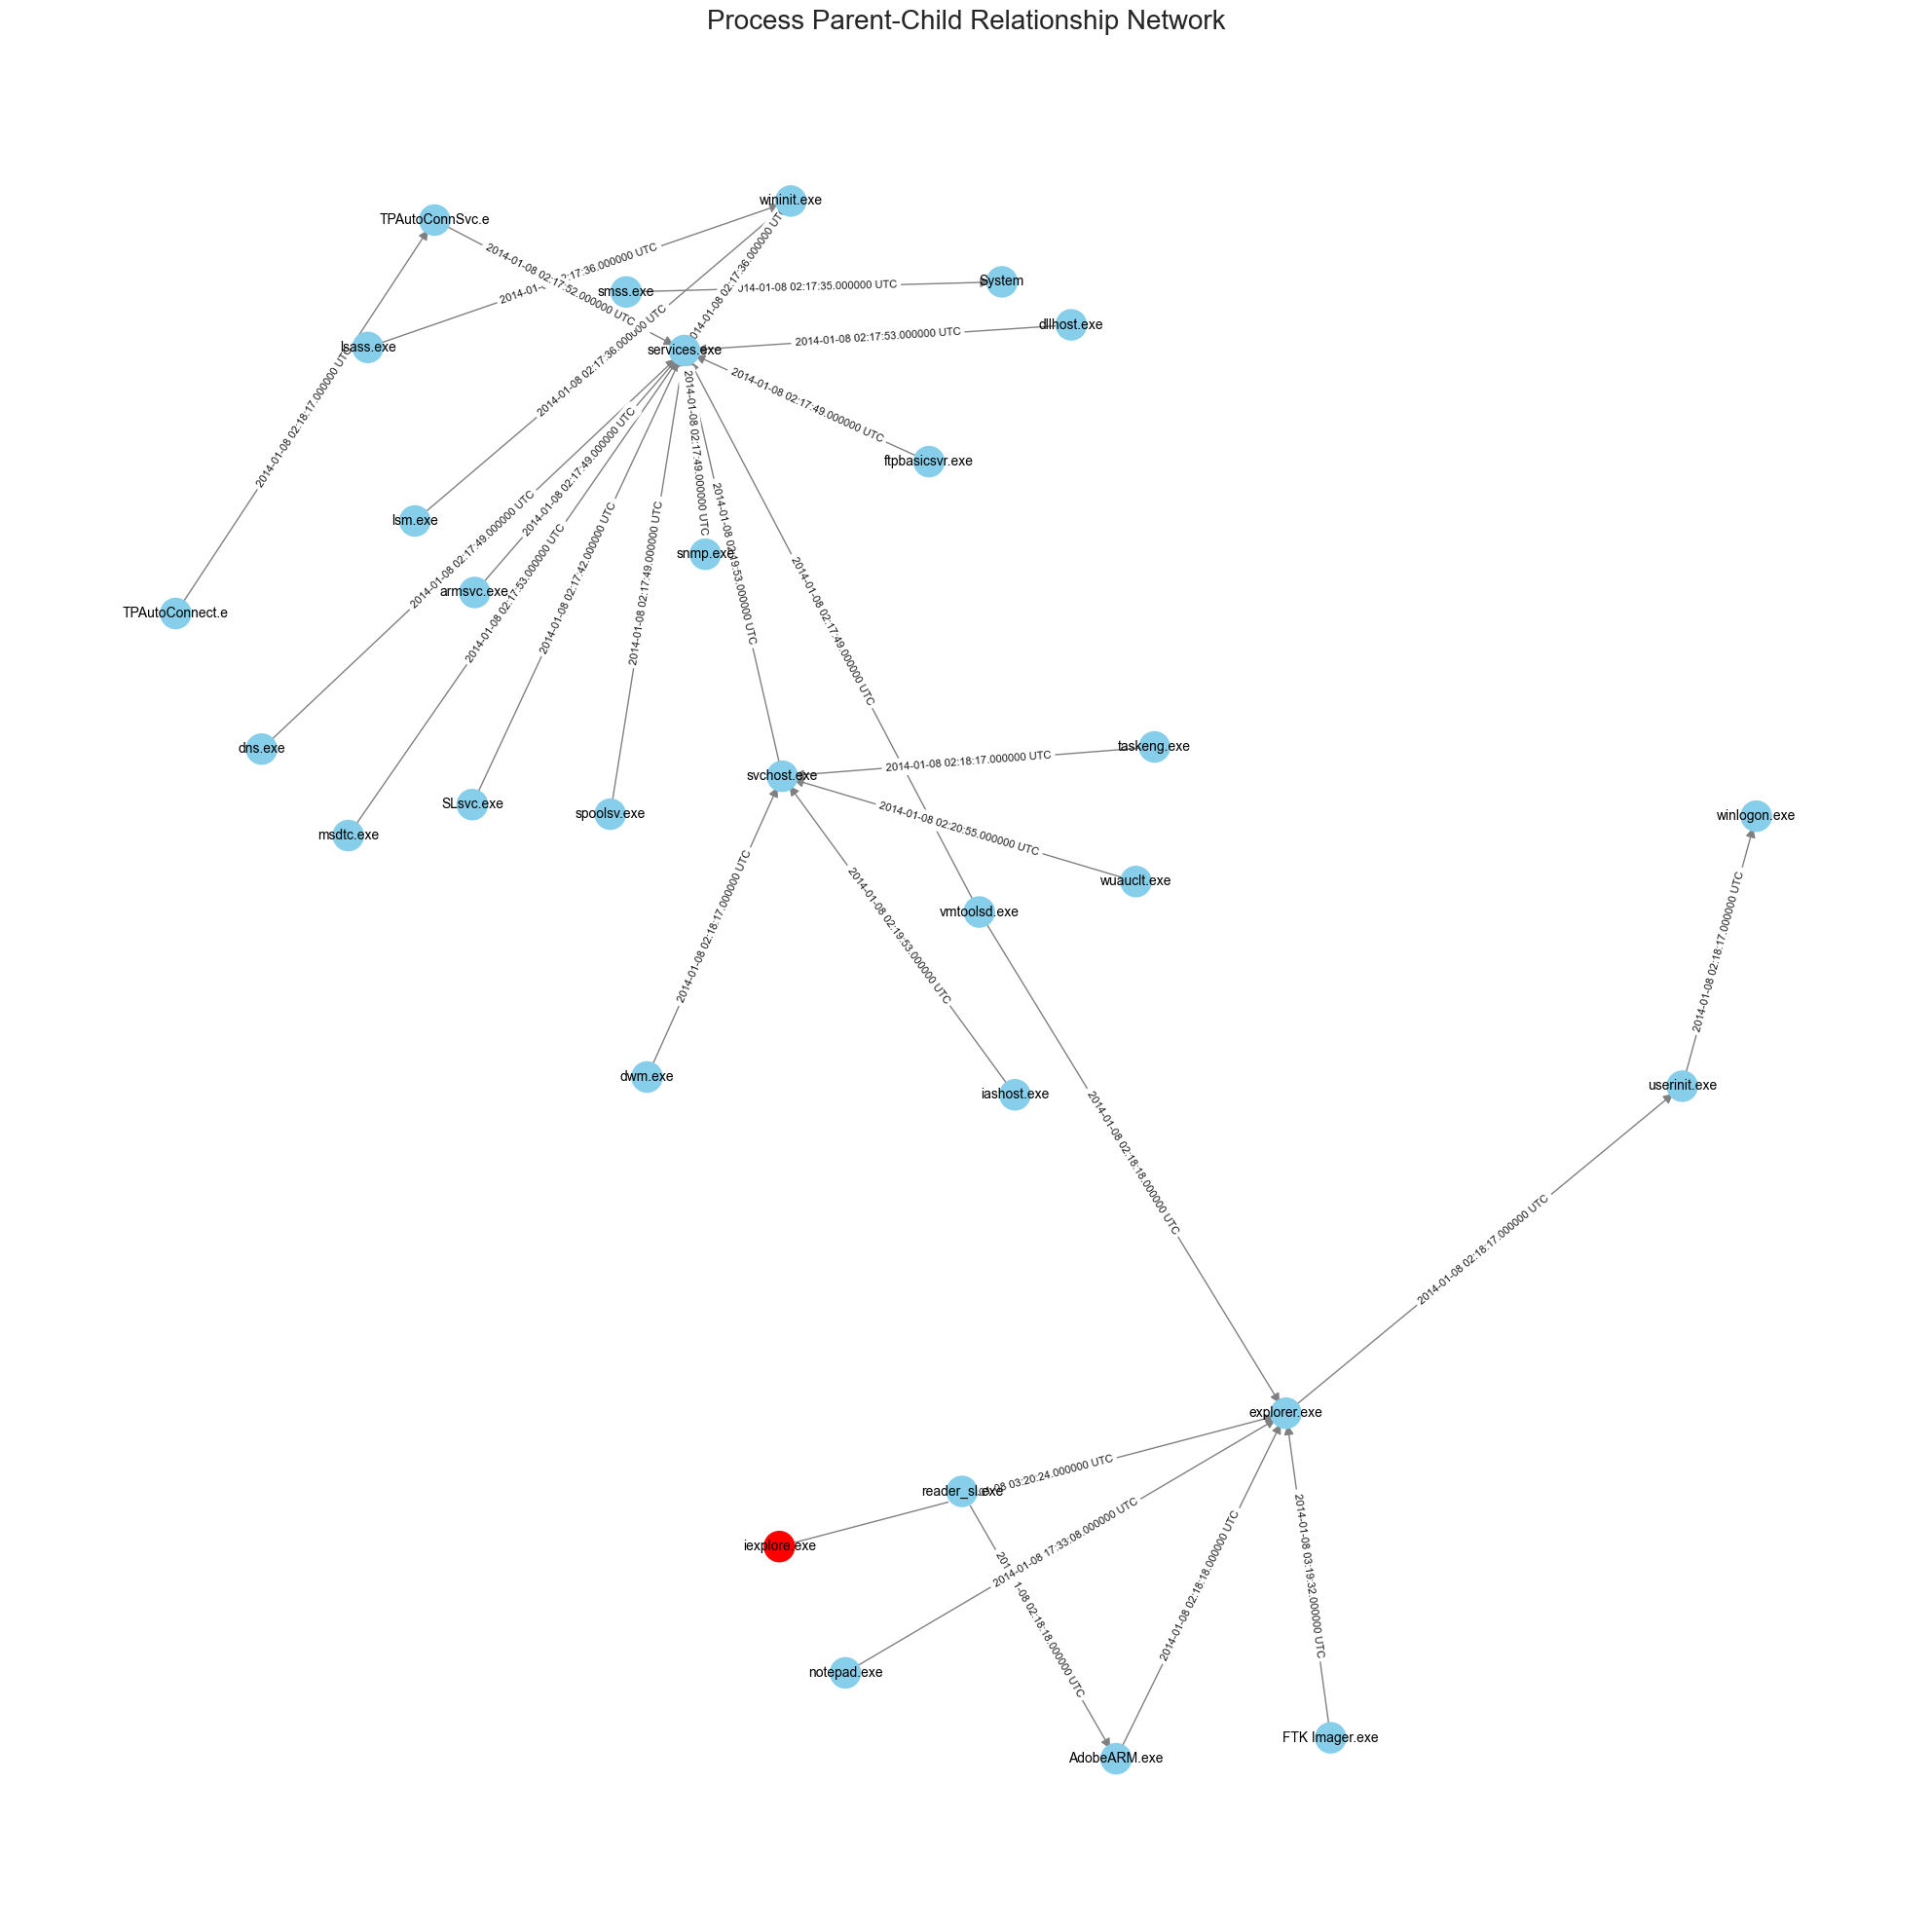

In [22]:
import networkx as nx
import matplotlib.pyplot as plt

# Define suspicious processes to highlight
suspicious_procs = ["powershell.exe", "cmd.exe", "iexplore.exe", "rundll32.exe"]

# Filter only rows with valid ParentName to avoid errors
df_network = dfprocs[dfprocs["ParentName"].notna() & (dfprocs["ParentName"] != "")]

# Create directed graph from parent-child relationships
G = nx.from_pandas_edgelist(
    df_network,
    source='ImageFileName',
    target='ParentName',
    edge_attr='CreateTime',  # optional, will display on edges
    create_using=nx.DiGraph()
)

# Set positions using spring layout (reduces overlap)
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Assign colors: red for suspicious, green for others
node_colors = [
    'red' if node.lower() in suspicious_procs else 'skyblue'
    for node in G.nodes()
]

# Increase figure size for better clarity
plt.figure(figsize=(20, 20))  # You can adjust size

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=500, node_color=node_colors)

# Draw edges
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=15, edge_color='gray')

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

# Draw edge labels (optional)
edge_labels = nx.get_edge_attributes(G, 'CreateTime')
if edge_labels:
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

# Title and formatting
plt.title("Process Parent-Child Relationship Network", fontsize=20)
plt.axis('off')  # Hide axis
plt.tight_layout()
plt.show()

## Focused Suspicious Process Network

This visualization highlights parent-child process relationships in memory, focusing on suspicious processes. Suspicious processes are colored red.

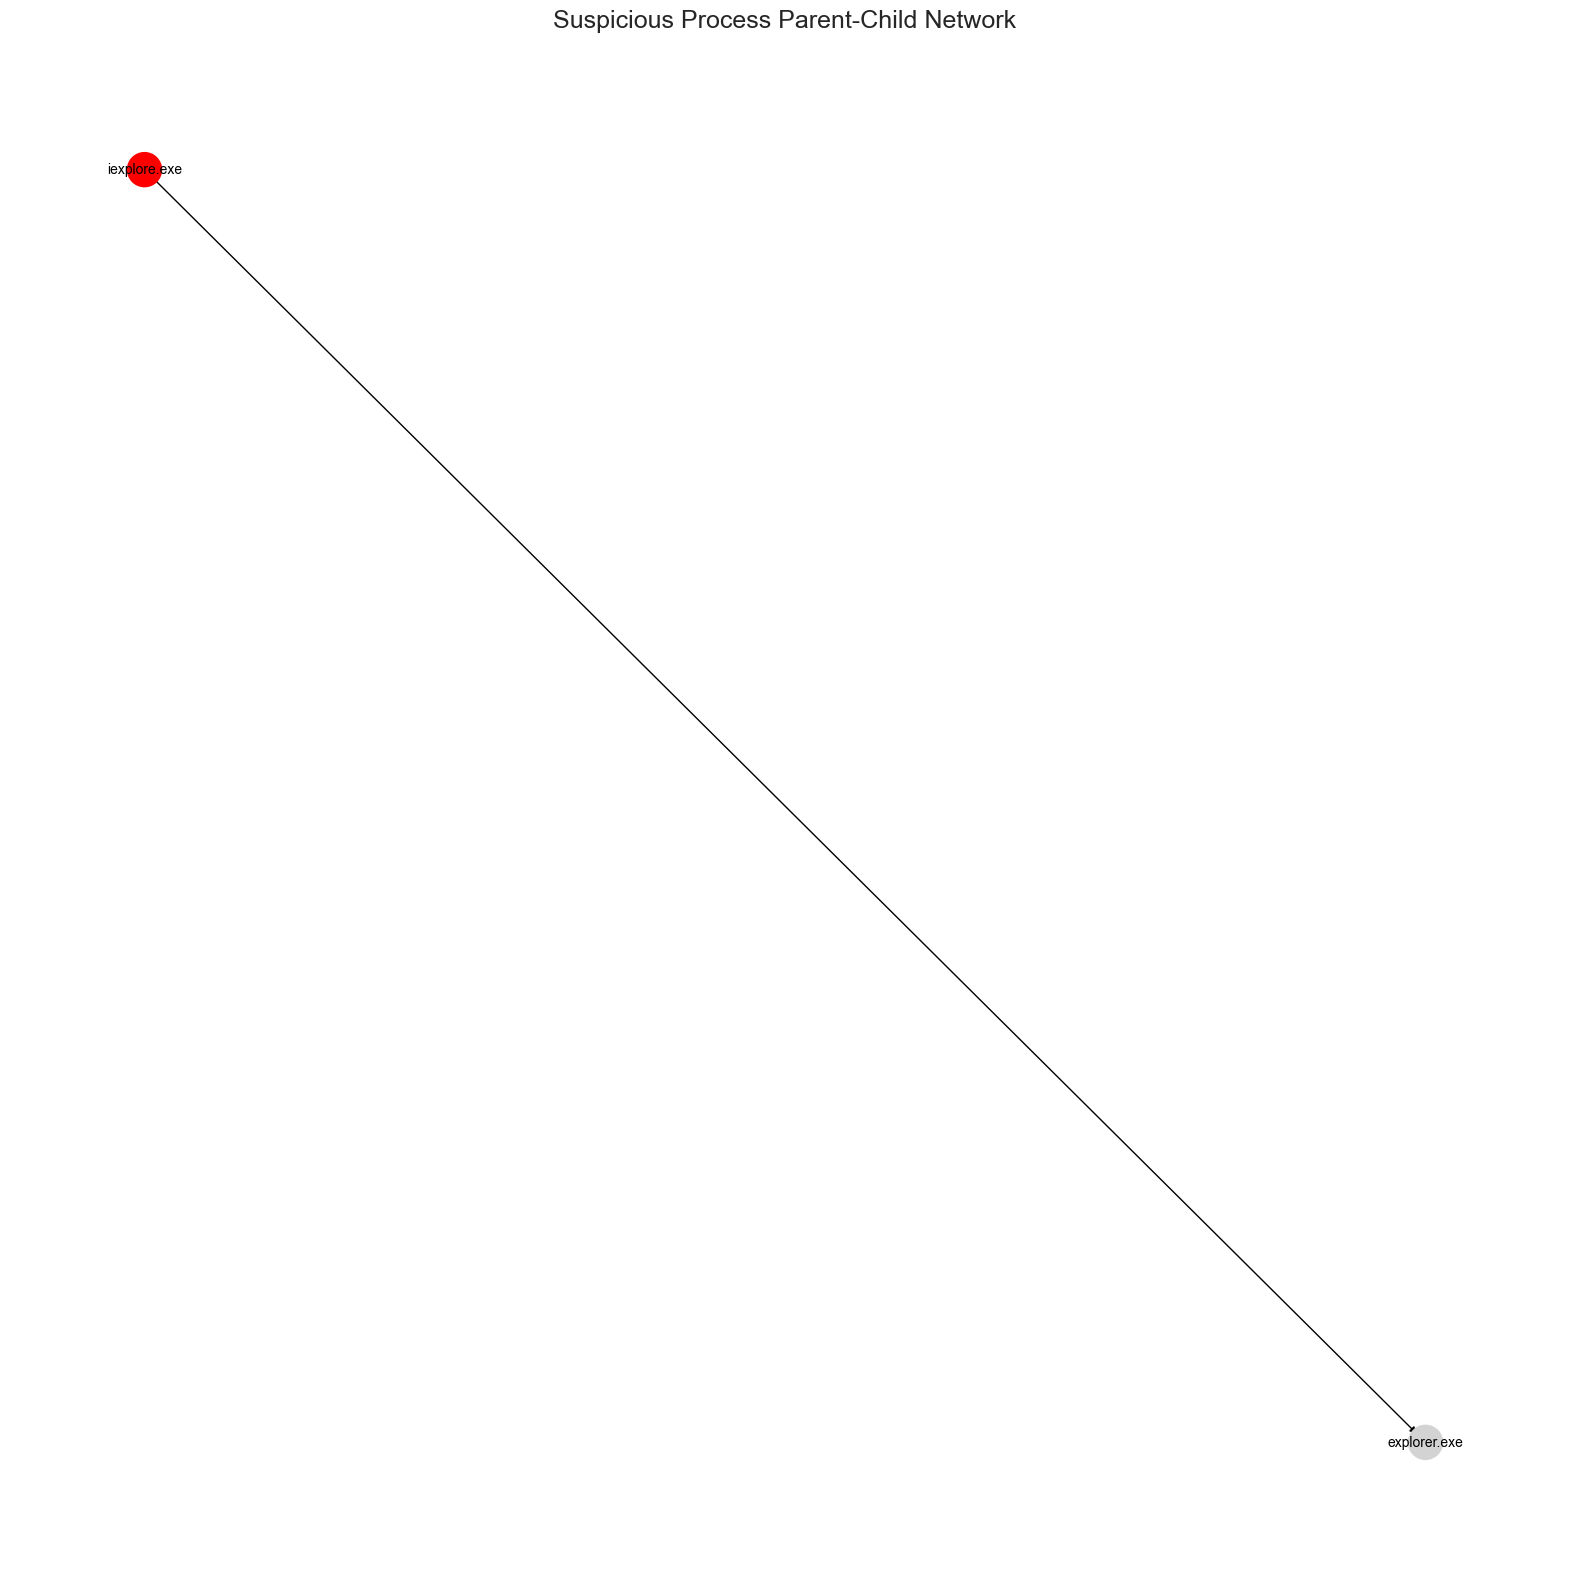

In [23]:
# PR7 – Focused Suspicious Process Network
# Visualize only suspicious processes and their parent-child relationships
# Suspicious processes are highlighted in red, parents included in gray

import networkx as nx
import matplotlib.pyplot as plt

# Define suspicious processes
suspicious_procs = ["powershell.exe", "cmd.exe", "iexplore.exe", "rundll32.exe"]

# Filter dataframe to include:
# 1. Suspicious processes themselves
# 2. Their parent processes (for context)
df_suspicious = dfprocs[
    (dfprocs['ImageFileName'].str.lower().isin(suspicious_procs)) |
    (dfprocs['ParentName'].str.lower().isin(suspicious_procs))
].copy()

# Remove rows where ParentName is NaN or empty
df_suspicious = df_suspicious[df_suspicious['ParentName'].notna() & (df_suspicious['ParentName'] != "")]

# Create directed graph
G = nx.from_pandas_edgelist(
    df_suspicious,
    source='ImageFileName',
    target='ParentName',
    create_using=nx.DiGraph()
)

# Assign colors: red for suspicious, gray for parent/context
node_color = [
    'red' if node.lower() in suspicious_procs else 'lightgray'
    for node in G.nodes()
]

# Plot graph
plt.figure(figsize=(20, 20))
pos = nx.spring_layout(G, k=0.5, iterations=100)  # Spring layout for better spacing

nx.draw_networkx_nodes(G, pos, node_size=600, node_color=node_color)
nx.draw_networkx_edges(G, pos, edge_color='black', arrows=True)
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

plt.title('Suspicious Process Parent-Child Network', fontsize=18)
plt.axis('off')
plt.show()

## Process to Network Connection Mapping

In [24]:
# Merge network connections with process names
dfproc_net = dfnetscan.merge(dfprocs[['PID','ImageFileName']], on='PID', how='left')

# Possible column names from netscan
possible_columns = [
    'PID','ImageFileName',
    'LocalAddr','LocalAddress',
    'LocalPort',
    'ForeignAddr','RemoteAddr','RemoteAddress',
    'ForeignPort','RemotePort',
    'State'
]

# Select only columns that exist
columns_to_display = [col for col in possible_columns if col in dfproc_net.columns]

# Display results
display(dfproc_net[columns_to_display])

,PID,ImageFileName,LocalAddr,LocalPort,ForeignAddr,ForeignPort,State
0,1088,svchost.exe,0.0.0.0,56153,*,0,NaN
1,1088,svchost.exe,::,56153,*,0,NaN
2,1088,svchost.exe,0.0.0.0,56152,*,0,NaN
3,4,System,0.0.0.0,1701,*,0,NaN
4,4,System,::,1701,*,0,NaN
5,604,services.exe,0.0.0.0,1031,0.0.0.0,0,LISTENING
6,604,services.exe,::,1031,::,0,LISTENING
7,604,services.exe,0.0.0.0,1031,0.0.0.0,0,LISTENING
8,604,services.exe,::,1031,::,0,LISTENING
9,4,System,0.0.0.0,1701,*,0,NaN


# External Communication Process Network

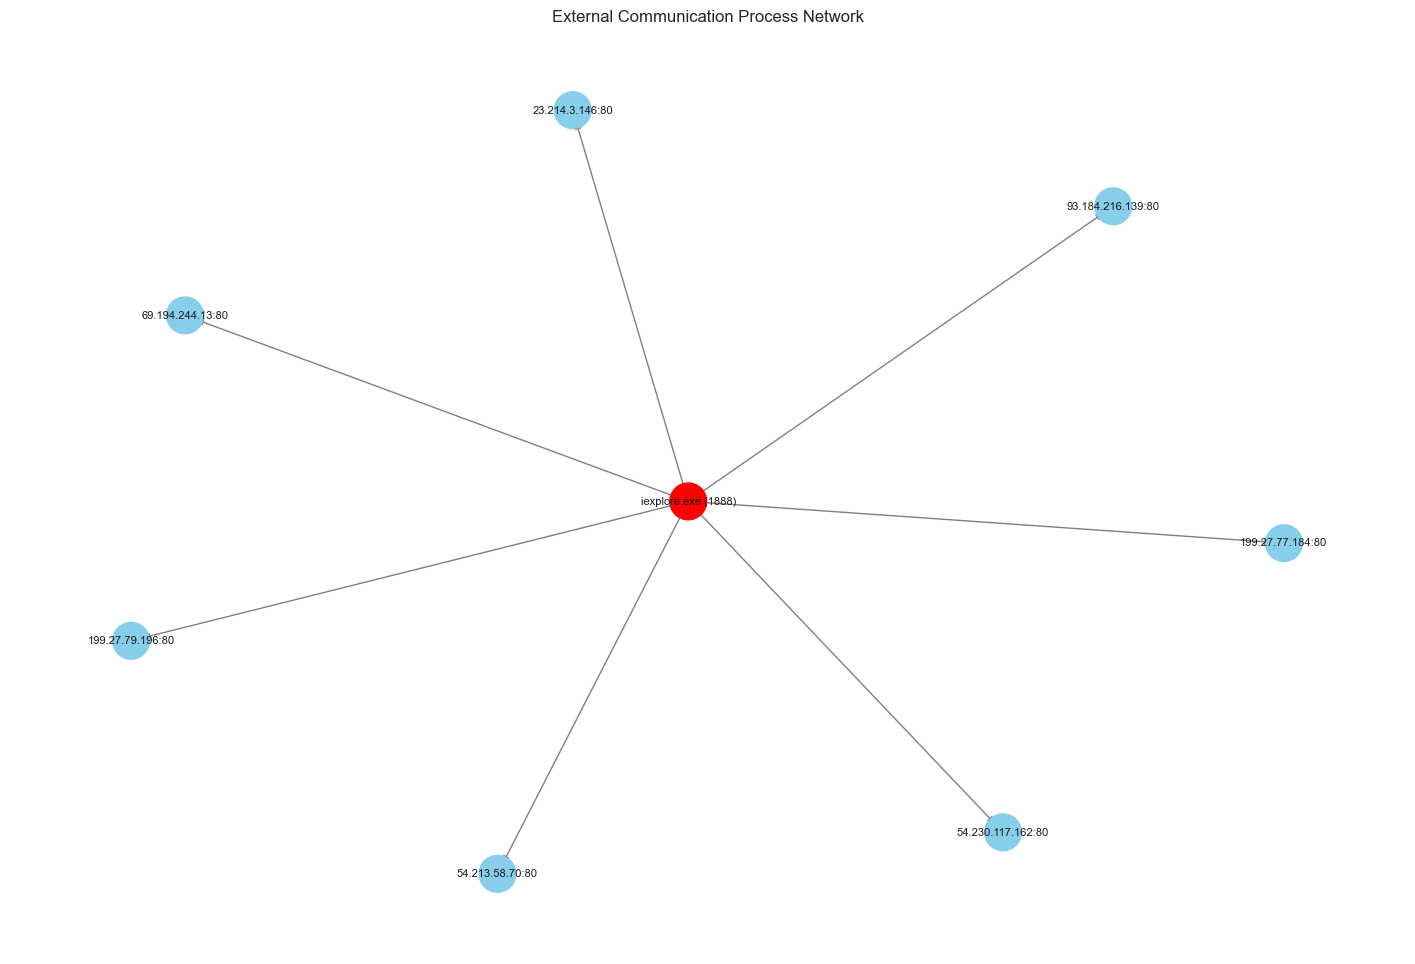

,PID,ImageFileName,ForeignAddr,ForeignPort,State
21,1888,iexplore.exe,54.213.58.70,80,CLOSED
23,1888,iexplore.exe,54.230.117.162,80,CLOSED
24,1888,iexplore.exe,93.184.216.139,80,CLOSED
25,1888,iexplore.exe,23.214.3.146,80,CLOSED
61,1888,iexplore.exe,199.27.79.196,80,CLOSED
65,1888,iexplore.exe,199.27.79.196,80,CLOSED
69,1888,iexplore.exe,199.27.77.184,80,CLOSED
71,1888,iexplore.exe,69.194.244.13,80,CLOSED
72,1888,iexplore.exe,199.27.77.184,80,CLOSED


In [25]:
# PR8c – External Communication Network Graph with Remote Endpoints

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Suspicious processes
suspicious_procs = ["powershell.exe","cmd.exe","iexplore.exe","rundll32.exe","svchost.exe"]

# Merge netscan with process list
dfproc_net = dfnetscan.merge(dfprocs[['PID','ImageFileName']], on='PID', how='left')

# Detect correct remote address column
remote_addr_col = None
remote_port_col = None

for c in ['RemoteAddress','RemoteAddr','ForeignAddr']:
    if c in dfproc_net.columns:
        remote_addr_col = c
        break

for c in ['RemotePort','ForeignPort']:
    if c in dfproc_net.columns:
        remote_port_col = c
        break

# Filter external connections
df_ext = dfproc_net[
    (dfproc_net[remote_addr_col].notna()) &
    (~dfproc_net[remote_addr_col].isin(['0.0.0.0','::','127.0.0.1','*']))
].copy()

# Build graph
G = nx.DiGraph()

for _, row in df_ext.iterrows():

    proc = f"{row['ImageFileName']} ({row['PID']})"
    remote = f"{row[remote_addr_col]}:{row[remote_port_col]}"

    G.add_node(proc, type="process",
               suspicious=str(row['ImageFileName']).lower() in suspicious_procs)

    G.add_node(remote, type="remote")

    G.add_edge(proc, remote)

# Assign colors
colors = []
for n in G.nodes():

    node = G.nodes[n]

    if node['type'] == "remote":
        colors.append("skyblue")

    elif node.get("suspicious"):
        colors.append("red")

    else:
        colors.append("green")

# Draw graph
plt.figure(figsize=(18,12))

pos = nx.spring_layout(G, k=1.3, iterations=200)

nx.draw_networkx_nodes(G,pos,node_color=colors,node_size=700)
nx.draw_networkx_edges(G,pos,edge_color="gray",arrows=True)
nx.draw_networkx_labels(G,pos,font_size=8)

plt.title("External Communication Process Network")
plt.axis("off")

plt.show()

# Show table
display_cols = ['PID','ImageFileName',remote_addr_col,remote_port_col,'State']
display_cols = [c for c in display_cols if c in df_ext.columns]

display(df_ext[display_cols])

<a href=#pr_up6>Process to Network Connection Mapping with Visual Diagram</a>

Description:

This analysis maps running processes to their network connections, providing both a tabular view and an interactive visual diagram. Each process is represented as a node, with edges connecting it to its corresponding network endpoint (IP:Port). Suspicious or commonly abused processes such as powershell.exe, cmd.exe, iexplore.exe, rundll32.exe, and svchost.exe are highlighted in red for easier identification. This visualization allows analysts to quickly spot unusual network activity, external communications, and potential command-and-control channels. Local-only connections (e.g., 127.0.0.1, 0.0.0.0) can be optionally filtered out to focus on external network activity.

Color Meaning

🔴 Red	Suspicious processes
🟢 Green	Normal processes
🔵 Blue	Remote IP connections
🟠 Orange	Local IP connections

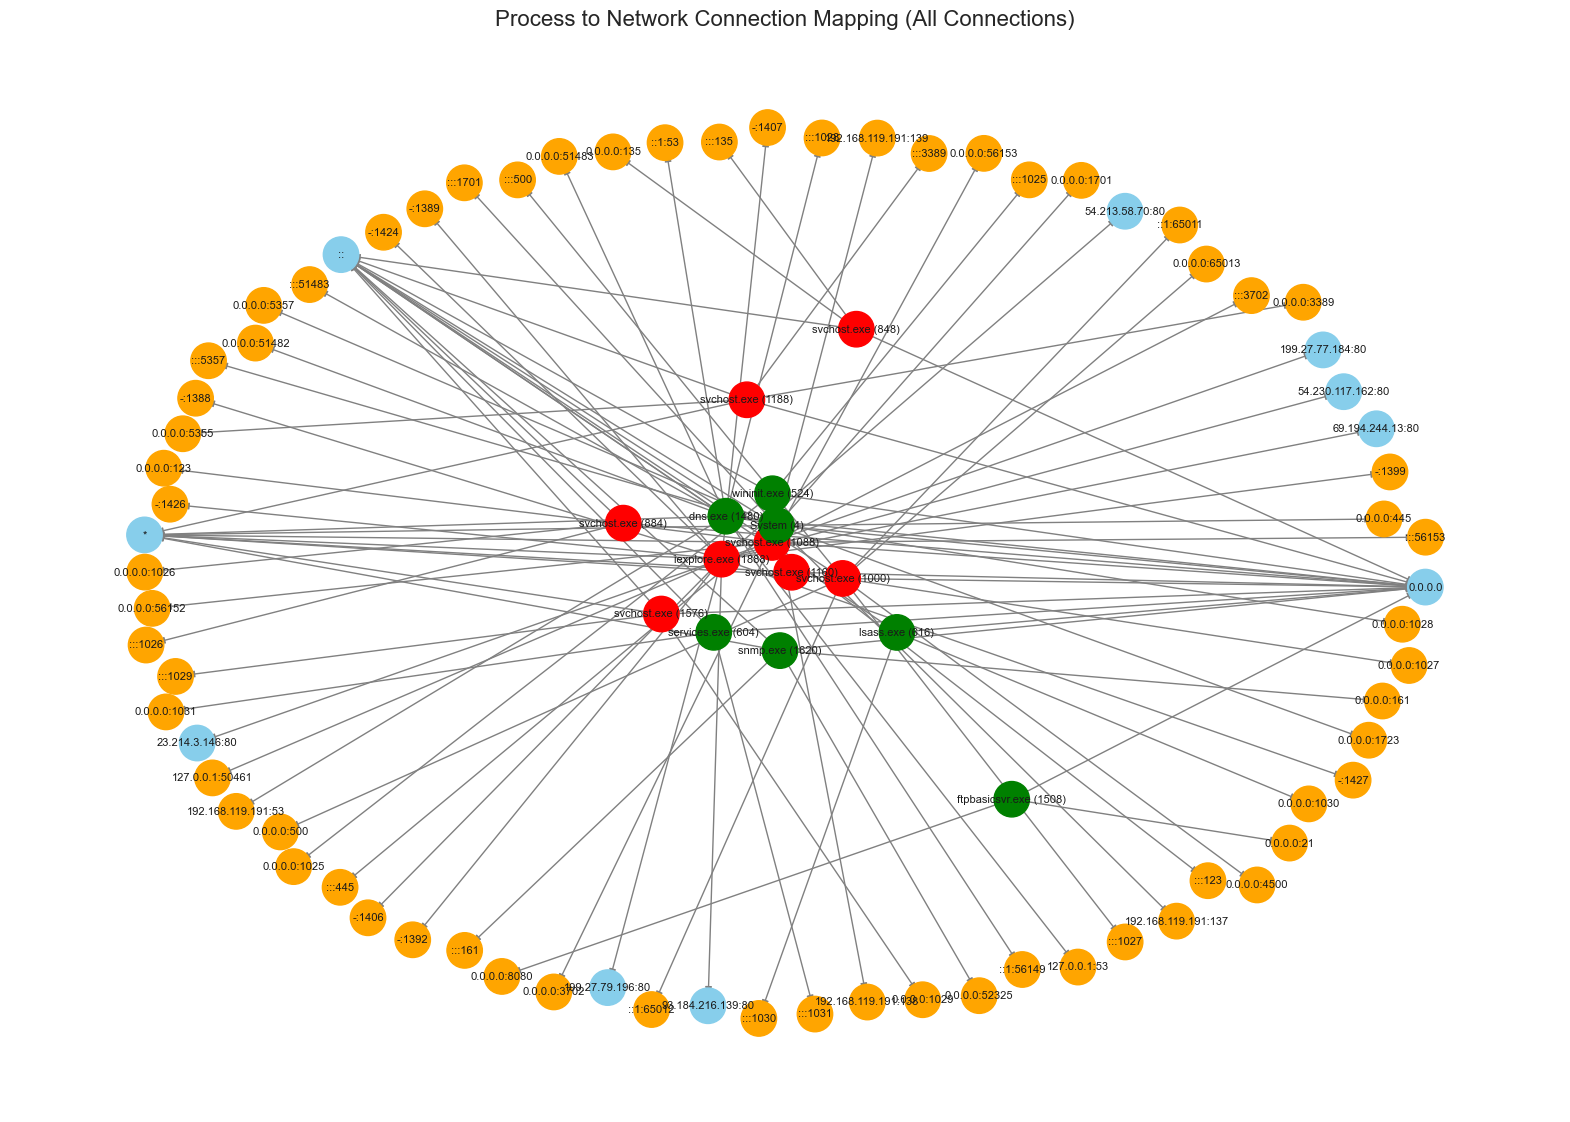

[i] Process to Network Connections Table


,PID,ImageFileName,LocalAddr,LocalPort,ForeignAddr,ForeignPort,State
0,1088,svchost.exe,0.0.0.0,56153,*,0,NaN
1,1088,svchost.exe,::,56153,*,0,NaN
2,1088,svchost.exe,0.0.0.0,56152,*,0,NaN
3,4,System,0.0.0.0,1701,*,0,NaN
4,4,System,::,1701,*,0,NaN
5,604,services.exe,0.0.0.0,1031,0.0.0.0,0,LISTENING
6,604,services.exe,::,1031,::,0,LISTENING
7,604,services.exe,0.0.0.0,1031,0.0.0.0,0,LISTENING
8,604,services.exe,::,1031,::,0,LISTENING
9,4,System,0.0.0.0,1701,*,0,NaN


In [26]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from colorama import Fore

# Suspicious processes often abused by malware
suspicious_procs = ["powershell.exe", "cmd.exe", "iexplore.exe", "rundll32.exe", "svchost.exe"]

# Merge process and network data
dfproc_net = dfnetscan.merge(dfprocs[['PID','ImageFileName']], on='PID', how='left')

# Detect correct column names automatically
local_addr_col = next((c for c in ['LocalAddress','LocalAddr'] if c in dfproc_net.columns), None)
remote_addr_col = next((c for c in ['RemoteAddress','RemoteAddr','ForeignAddr'] if c in dfproc_net.columns), None)

local_port_col = next((c for c in ['LocalPort'] if c in dfproc_net.columns), None)
remote_port_col = next((c for c in ['RemotePort','ForeignPort'] if c in dfproc_net.columns), None)

# Create directed graph
G_net = nx.DiGraph()

for _, row in dfproc_net.iterrows():

    proc_name = str(row['ImageFileName'])
    proc_node = f"{proc_name} ({row['PID']})"

    suspicious = proc_name.lower() in suspicious_procs

    # Add process node
    G_net.add_node(proc_node, type='process', suspicious=suspicious)

    # Add LOCAL connection
    if local_addr_col and pd.notna(row[local_addr_col]):
        local_ip = row[local_addr_col]
        local_port = row[local_port_col] if local_port_col else ""

        local_node = f"{local_ip}:{local_port}" if local_port else str(local_ip)

        G_net.add_node(local_node, type='local')
        G_net.add_edge(proc_node, local_node)

    # Add REMOTE connection
    if remote_addr_col and pd.notna(row[remote_addr_col]):
        remote_ip = row[remote_addr_col]
        remote_port = row[remote_port_col] if remote_port_col else ""

        remote_node = f"{remote_ip}:{remote_port}" if remote_port else str(remote_ip)

        G_net.add_node(remote_node, type='remote')
        G_net.add_edge(proc_node, remote_node)

# Assign colors
node_colors = []
for node in G_net.nodes():

    node_data = G_net.nodes[node]

    if node_data.get('type') == 'remote':
        node_colors.append('skyblue')

    elif node_data.get('type') == 'local':
        node_colors.append('orange')

    elif node_data.get('suspicious'):
        node_colors.append('red')

    else:
        node_colors.append('green')

# Draw graph
plt.figure(figsize=(20,14))

pos = nx.spring_layout(G_net, k=1.4, iterations=200)

nx.draw_networkx_nodes(G_net, pos, node_size=650, node_color=node_colors)
nx.draw_networkx_edges(G_net, pos, edge_color='gray', arrows=True)
nx.draw_networkx_labels(G_net, pos, font_size=8)

plt.title("Process to Network Connection Mapping (All Connections)", fontsize=16)
plt.axis('off')

plt.show()

# Display connection table
display_cols = ['PID','ImageFileName',local_addr_col,local_port_col,remote_addr_col,remote_port_col,'State']
display_cols = [c for c in display_cols if c in dfproc_net.columns]

print(Fore.CYAN + "[i] Process to Network Connections Table")
display(dfproc_net[display_cols])

### <a href=#pr7>IN7 - Anomalous Process Detection using Time Duration</a>
This analyst task focuses on visually analyzing the lifetime of processes at the time the memory dump was captured. Processes with a very short lifespan may be suspicious and could require further investigation. In addition, analysts may identify malicious or abnormal process behavior by observing the process creation and termination timeline as processes appear and disappear over time.

To reduce noise, a new dataframe is first created that only includes processes with exit timestamps, filtering out processes that are still running. After preparing the dataset, a Timeline Duration visualization is generated using the msticpy library. This visualization helps analysts quickly identify processes with unusually short execution times or irregular activity patterns.

In [27]:
dfprocs_exit = dfprocs[dfprocs.ExitTime.notnull()]
mp.vis.timeline_duration.display_timeline_duration(dfprocs_exit, group_by="ImageFileName", time_column="CreateTime", end_time_column="ExitTime")

Loading BokehJS ...

Column(id='p1207', ...)

### <a href=#PR8>IN8 - Detection of Suspicious Command-Line Arguments</a>
Description:

This analysis examines command-line arguments used by running processes to identify indicators commonly associated with malicious activity. Attackers often execute tools such as PowerShell, certutil, bitsadmin, or mshta with obfuscated or encoded commands to download payloads, execute scripts in memory, or evade detection.

The detection logic searches for patterns including Base64 encoded commands, PowerShell execution flags, web download functions, credential dumping indicators (sekurlsa), and other suspicious execution techniques. Identifying these command-line artifacts can help analysts quickly detect living-off-the-land attacks, fileless malware execution, and privilege escalation attempts within the memory image.

In [28]:
sus_cmdargs = dfcmdline[dfcmdline["Args"].str.match(r".*(nop|NoLogo|noni|invoke-expression|WebClient|EncodedCommand|nop|reflection\.assembly|-enc|IO\.Compression|DownloadString|System\.Net\.WebClient|Hidden|iex|FromBase64|powershell\.cpl|base64|MemoryStream)|COMSPEC|IABz|SQBFAFgA|aWV4I|aQBlAHgA|SUVYI|sekurlsa|(whoami|certutil|bitsadmin|mshta|StartW|MiniDump|comsvcs\.dll).*", case=False) == True][['PID','Process','Args']]
if (sus_cmdargs.empty):
    print(Fore.GREEN + "[✓]No suspicious commandline arguments detected")
else:
    print(Fore.RED + "[!]Suspicious commandline arguments detected!")
    print(sus_cmdargs.to_string(index = False))

[!]Suspicious commandline arguments detected!
 PID      Process                                                  Args
1888 iexplore.exe "C:\\Program Files\\Internet Explorer\\iexplore.exe" 


#### Enhanced Suspicious Command-line Detection

Description:

This rule identifies truly suspicious process arguments often seen in intrusions, including:

1. Encoded PowerShell commands (-enc, EncodedCommand, FromBase64String)
2. Fileless attack indicators (Invoke-Expression, IEX)
3. Downloaders / C2 activity (DownloadString, WebClient, System.Net.WebClient)
4. Credential dumping or malware libraries (sekurlsa, comsvcs.dll)
5. Command-line obfuscation patterns (nop, MemoryStream, Hidden)

We also filter out normal processes that might include innocuous arguments, reducing false positives.

In [29]:
import re
from colorama import Fore

# List of malicious patterns to search for
malicious_patterns = [
    r"-enc",                     # Base64 encoded PowerShell
    r"EncodedCommand",
    r"FromBase64",                # Obfuscated command
    r"iex",                       # Invoke-Expression shorthand
    r"invoke-expression",
    r"DownloadString",
    r"System\.Net\.WebClient",
    r"Hidden",
    r"MemoryStream",
    r"nop",
    r"COMSPEC",
    r"sekurlsa",                  # Credential dumping
    r"certutil",                  # File download / decoding
    r"bitsadmin",
    r"mshta",
    r"MiniDump",
    r"comsvcs\.dll",
    r"Start-Process",             # Often abused in attacks
    r"WebClient",
]

# Combine into a single regex
pattern_regex = "|".join(malicious_patterns)

# Filter command-lines
sus_cmdargs = dfcmdline[
    dfcmdline["Args"].str.contains(pattern_regex, flags=re.IGNORECASE, na=False)
][['PID','Process','Args']]

# Display results
if sus_cmdargs.empty:
    print(Fore.GREEN + "[✓] No truly suspicious command-line arguments detected")
else:
    print(Fore.RED + "[!] Suspicious command-line arguments detected!")
    display(sus_cmdargs)

[!] Suspicious command-line arguments detected!


,PID,Process,Args
46,1888,iexplore.exe,"""C:\\Program Files\\Internet Explorer\\iexplore.exe"""


### <a href=#pr9>IN9 – IoC Extraction from Process Command Lines</a>

This task extracts Indicators of Compromise (IoCs) from process command-line arguments to help identify potentially malicious behavior. Using the IoCExtract tool (or a custom parser), it scans process arguments for IP addresses, URLs, domains, file hashes, and encoded commands. The resulting table allows analysts to quickly identify suspicious network endpoints, malware download locations, or other indicators embedded in running processes. This is a key step in threat hunting and memory forensics to correlate suspicious process activity with known IoCs.

In [30]:
from msticpy.transform.iocextract import IoCExtract

ioc_extractor = IoCExtract()

# Extract all default IoC types from the Args column
ioc_df = ioc_extractor.extract(data=dfcmdline, columns=['Args'])

# Display results only if any IoCs found
if not ioc_df.empty:
    print("[!] IoC patterns found in process command-lines")
    display(ioc_df)
else:
    print("[✓] No IoC patterns found in process command-lines")

[✓] No IoC patterns found in process command-lines


### <a href=#PR9>IN10 - Suspicious rundll32.exe Parent Process Detection</a>
This task focuses on detecting instances where rundll32.exe is spawned by unusual or suspicious parent processes. Normally, rundll32.exe should be launched by system processes for legitimate DLL execution. However, if it is spawned by processes such as winword.exe, excel.exe, msaccess.exe, taskeng.exe, winlogon.exe, schtask.exe, regsvr32.exe, or other unexpected parents, it may indicate malicious activity, such as macro-based malware execution, persistence mechanisms, or lateral movement.

This check allows analysts to quickly identify and investigate potential misuse of rundll32.exe in the memory image or running system, providing a focused view of suspicious parent-child process relationships.

In [31]:
susdllloc = dfprocs[((dfprocs.ImageFileName.str.lower() == "rundll32.exe")) & (dfprocs.ParentName.str.lower().isin(['winword.exe', 'excel.exe','msaccess.exe','lsass.exe','taskeng.exe','winlogon.exe','schtask.exe','regsvr32.exe','wmiprvse.exe','wsmprovhost.exe']))][['ImageFileName','PID','PPID','ParentName']]
if (susdllloc.empty):
    print(Fore.GREEN + "[✓]No suspicious rundll32 parent detected")
else:
    print(Fore.RED + "[!]Suspicious rundll32.exe parent detected!")
    print(susdllloc.to_string(index = False))

[✓]No suspicious rundll32 parent detected


In [32]:
from colorama import Fore

# Define suspicious parent processes
suspicious_parents = [
    'winword.exe', 'excel.exe', 'msaccess.exe',
    'lsass.exe', 'taskeng.exe', 'winlogon.exe',
    'schtask.exe', 'regsvr32.exe', 'wmiprvse.exe',
    'wsmprovhost.exe'
]

# Filter for rundll32.exe spawned by suspicious parents
susdllloc = dfprocs[
    (dfprocs.ImageFileName.str.lower() == "rundll32.exe") &
    (dfprocs.ParentName.str.lower().isin(suspicious_parents))
][['ImageFileName','PID','PPID','ParentName']]

if susdllloc.empty:
    print(Fore.GREEN + "[✓] No suspicious rundll32.exe parent detected")
else:
    print(Fore.RED + f"[!] Suspicious rundll32.exe parent detected! Total: {len(susdllloc)}")
    display(susdllloc)

    # Optional: count occurrences per parent
    parent_counts = susdllloc['ParentName'].value_counts().reset_index()
    parent_counts.columns = ['Suspicious Parent', 'Count of rundll32.exe']
    print(Fore.YELLOW + "[i] Count of suspicious rundll32.exe instances per parent process:")
    display(parent_counts)

[✓] No suspicious rundll32.exe parent detected


### <a href=#NT1>GP 1 - Visual network interactions</a>
Description:

This visualization provides a quick overview of network activity by plotting the intersections between source (Local) and destination (Foreign) IPs. Connections are displayed in descending order to highlight the most frequent interactions. Analysts can use this matrix to identify unusual communication patterns, repeated external connections, or potential command-and-control endpoints.

In [33]:
from msticpy.vis.matrix_plot import plot_matrix

# Visualize intersections between local and foreign IPs
plot_matrix(
    data=dfnetscan,         # Network scan dataframe
    x="ForeignAddr",        # Destination IPs
    y="LocalAddr",          # Source IPs
    title="IP Interactions",
    sort="dsc",             # Sort descending to highlight most frequent interactions
    intersect=True          # Show confirmed intersects
)

Loading BokehJS ...

figure(id='p1281', ...)

Testing$$$$$$$$$$$$$$$$$$$$$$$$$$$








Testing $$$$$$$$

### <a href=#NT2>NT2 - No of external network communications per public IP</a>
The following bar chart shows external network connections with the number of occurrences within the memory image.

<Axes: xlabel='ForeignAddr'>

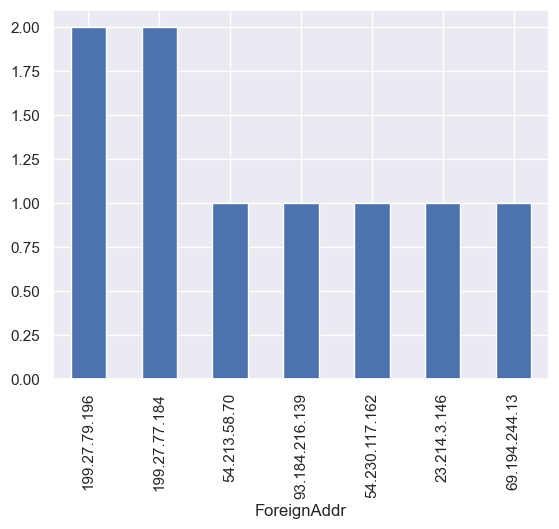

In [34]:
dfnetscan[(dfnetscan["ForeignAddr"].str.match(r'(?!^0\.)(?!^10\.)(?!^100\.6[4-9]\.)(?!^100\.[7-9]\d\.)(?!^100\.1[0-1]\d\.)(?!^100\.12[0-7]\.)(?!^127\.)(?!^169\.254\.)(?!^172\.1[6-9]\.)(?!^172\.2[0-9]\.)(?!^172\.3[0-1]\.)(?!^192\.0\.0\.)(?!^192\.0\.2\.)(?!^192\.88\.99\.)(?!^192\.168\.)(?!^198\.1[8-9]\.)(?!^198\.51\.100\.)(?!^203.0\.113\.)(?!^22[4-9]\.)(?!^23[0-9]\.)(?!^24[0-9]\.)(?!^25[0-5]\.)(([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])\.([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])\.([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])\.([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5]))$') == True)]["ForeignAddr"].value_counts().plot(kind='bar')

### <a href=#NT3>NT3 - Intelligence matches for external network connections</a>
Closed network connections that communicate with public IPs may be of interest.

In [35]:
ext_netclose = dfnetscan[(dfnetscan["ForeignAddr"].str.match(r'(?!^0\.)(?!^10\.)(?!^100\.6[4-9]\.)(?!^100\.[7-9]\d\.)(?!^100\.1[0-1]\d\.)(?!^100\.12[0-7]\.)(?!^127\.)(?!^169\.254\.)(?!^172\.1[6-9]\.)(?!^172\.2[0-9]\.)(?!^172\.3[0-1]\.)(?!^192\.0\.0\.)(?!^192\.0\.2\.)(?!^192\.88\.99\.)(?!^192\.168\.)(?!^198\.1[8-9]\.)(?!^198\.51\.100\.)(?!^203.0\.113\.)(?!^22[4-9]\.)(?!^23[0-9]\.)(?!^24[0-9]\.)(?!^25[0-5]\.)(([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])\.([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])\.([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])\.([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5]))$') == True)][["ForeignAddr","ForeignPort","Owner"]]
if (ext_netclose.empty):
    print(Fore.GREEN + "[✓]No closed external connections were detected")
else:
    print(Fore.RED + "[!]Terminated external network connections detected")
    ext_netclose.to_string(index = False)
    print("\n")
    print("Positive Threat Intelligence Enrichment on the IPs")
    ext_netclose.drop_duplicates(subset ="ForeignAddr", keep = False, inplace = True)
    resraw_intel = intel.lookup_iocs(data=ext_netclose, ioc_col="ForeignAddr")
    res_intel = resraw_intel[resraw_intel["Result"]==True]
    
    #Dropping columns that are not required 
    res_intel_cut = res_intel.drop(['QuerySubtype','RawResult','Result'], axis=1)
    display(res_intel_cut)


[!]Terminated external network connections detected


Positive Threat Intelligence Enrichment on the IPs


Observables processed:   0%|          | 0/10 [00:00<?, ?obs/s]

,Details,Reference,Status,Ioc,IocType,SafeIoc,Severity,Provider
0,"{'Classification': 'benign', 'Name': 'Amazon CloudFront', 'Last Seen': '2026-03-24', 'Message': 'Success', 'Noise': False, 'RIOT': True}",https://api.greynoise.io/v3/community/54.230.117.162,0,54.230.117.162,ipv4,54.230.117.162,information,GreyNoise
0,"{'Classification': 'benign', 'Name': 'Akamai Technologies Cloud Services', 'Last Seen': '2026-03-24', 'Message': 'Success', 'Noise': False, 'RIOT': True}",https://api.greynoise.io/v3/community/23.214.3.146,0,23.214.3.146,ipv4,23.214.3.146,information,GreyNoise
0,"{'pulse_count': 0, 'sections_available': ['general', 'geo', 'reputation', 'url_list', 'passive_dns', 'malware', 'nids_list', 'http_scans']}",https://otx.alienvault.com/api/v1/indicators/IPv4/54.213.58.70/general,0,54.213.58.70,ipv4,54.213.58.70,information,OTX
0,"{'pulse_count': 0, 'sections_available': ['general', 'geo', 'reputation', 'url_list', 'passive_dns', 'malware', 'nids_list', 'http_scans']}",https://otx.alienvault.com/api/v1/indicators/IPv4/93.184.216.139/general,0,93.184.216.139,ipv4,93.184.216.139,information,OTX
0,"{'pulse_count': 0, 'sections_available': ['general', 'geo', 'reputation', 'url_list', 'passive_dns', 'malware', 'nids_list', 'http_scans']}",https://otx.alienvault.com/api/v1/indicators/IPv4/23.214.3.146/general,0,23.214.3.146,ipv4,23.214.3.146,information,OTX
0,"{'pulse_count': 0, 'sections_available': ['general', 'geo', 'reputation', 'url_list', 'passive_dns', 'malware', 'nids_list', 'http_scans']}",https://otx.alienvault.com/api/v1/indicators/IPv4/69.194.244.13/general,0,69.194.244.13,ipv4,69.194.244.13,information,OTX


### <a href=#NT4>NT4 - Suspicious web connections that are not related to browsers</a>
Web browsers usually communicate over port 80,443 or 8080. This shows processors which are not common browsers that communicate over those ports.

In [36]:
sus_http = dfnetscan[(dfnetscan["ForeignPort"] == 8080) | (dfnetscan["ForeignPort"] == 80) | (dfnetscan["ForeignPort"] == 443) & ((dfnetscan.Owner.str.lower() != "msmpeng.exe") & (dfnetscan.Owner.str.lower() != "chrome.exe") & (dfnetscan.Owner.str.lower() != "msedge.exe") & (dfnetscan.Owner.str.lower() != "firefox.exe") & (dfnetscan.Owner.str.lower() != "iexplorer.exe"))][["ForeignAddr","ForeignPort","Owner"]]
if (sus_http.empty):
    print(Fore.GREEN + "[✓]No suspicious web connections were detected")
else:
    print(Fore.RED + "[!]None browser based web connections were detected")
    print(sus_http.to_string(index = False))
    print("\n")
    print("Positive Threat Intelligence Enrichment on the IPs")
    resraw_intel2 = intel.lookup_iocs(data=sus_http, ioc_col="ForeignAddr", providers=["GreyNoise","OTX"])
    res_intel2 = resraw_intel2[resraw_intel2["Result"]==True]
    
    #Dropping columns that are not required 
    res_intel2_cut = res_intel2.drop(['QuerySubtype','RawResult','Result'], axis=1)
    display(res_intel2_cut)

[!]None browser based web connections were detected
   ForeignAddr  ForeignPort        Owner
  54.213.58.70           80 iexplore.exe
54.230.117.162           80 iexplore.exe
93.184.216.139           80 iexplore.exe
  23.214.3.146           80 iexplore.exe
 199.27.79.196           80 iexplore.exe
 199.27.79.196           80 iexplore.exe
 199.27.77.184           80 iexplore.exe
 69.194.244.13           80 iexplore.exe
 199.27.77.184           80 iexplore.exe


Positive Threat Intelligence Enrichment on the IPs


Observables processed:   0%|          | 0/18 [00:00<?, ?obs/s]

,Details,Reference,Status,Ioc,IocType,SafeIoc,Severity,Provider
0,"{'Classification': 'benign', 'Name': 'Amazon CloudFront', 'Last Seen': '2026-03-24', 'Message': 'Success', 'Noise': False, 'RIOT': True}",https://api.greynoise.io/v3/community/54.230.117.162,0,54.230.117.162,ipv4,54.230.117.162,information,GreyNoise
0,"{'Classification': 'benign', 'Name': 'Akamai Technologies Cloud Services', 'Last Seen': '2026-03-24', 'Message': 'Success', 'Noise': False, 'RIOT': True}",https://api.greynoise.io/v3/community/23.214.3.146,0,23.214.3.146,ipv4,23.214.3.146,information,GreyNoise
0,"{'Classification': 'benign', 'Name': 'Fastly', 'Last Seen': '2026-03-24', 'Message': 'Success', 'Noise': False, 'RIOT': True}",https://api.greynoise.io/v3/community/199.27.79.196,0,199.27.79.196,ipv4,199.27.79.196,information,GreyNoise
0,"{'Classification': 'benign', 'Name': 'Fastly', 'Last Seen': '2026-03-24', 'Message': 'Success', 'Noise': False, 'RIOT': True}",https://api.greynoise.io/v3/community/199.27.79.196,0,199.27.79.196,ipv4,199.27.79.196,information,GreyNoise
0,"{'Classification': 'benign', 'Name': 'Fastly', 'Last Seen': '2026-03-24', 'Message': 'Success', 'Noise': False, 'RIOT': True}",https://api.greynoise.io/v3/community/199.27.77.184,0,199.27.77.184,ipv4,199.27.77.184,information,GreyNoise
0,"{'Classification': 'benign', 'Name': 'Fastly', 'Last Seen': '2026-03-24', 'Message': 'Success', 'Noise': False, 'RIOT': True}",https://api.greynoise.io/v3/community/199.27.77.184,0,199.27.77.184,ipv4,199.27.77.184,information,GreyNoise
0,"{'pulse_count': 0, 'sections_available': ['general', 'geo', 'reputation', 'url_list', 'passive_dns', 'malware', 'nids_list', 'http_scans']}",https://otx.alienvault.com/api/v1/indicators/IPv4/54.213.58.70/general,0,54.213.58.70,ipv4,54.213.58.70,information,OTX
0,"{'pulse_count': 0, 'sections_available': ['general', 'geo', 'reputation', 'url_list', 'passive_dns', 'malware', 'nids_list', 'http_scans']}",https://otx.alienvault.com/api/v1/indicators/IPv4/93.184.216.139/general,0,93.184.216.139,ipv4,93.184.216.139,information,OTX
0,"{'pulse_count': 0, 'sections_available': ['general', 'geo', 'reputation', 'url_list', 'passive_dns', 'malware', 'nids_list', 'http_scans']}",https://otx.alienvault.com/api/v1/indicators/IPv4/23.214.3.146/general,0,23.214.3.146,ipv4,23.214.3.146,information,OTX
0,"{'pulse_count': 0, 'sections_available': ['general', 'geo', 'reputation', 'url_list', 'passive_dns', 'malware', 'nids_list', 'http_scans']}",https://otx.alienvault.com/api/v1/indicators/IPv4/199.27.79.196/general,0,199.27.79.196,ipv4,199.27.79.196,information,OTX


### <a href=#NT5>NT5 - IP address in commandline arguments</a>
Detect explicit use of IP addresses in command line arguments.

In [37]:
ip_cmdline = dfcmdline[dfcmdline["Args"].str.match(r'.*(?!^0\.)(?!^10\.)(?!^100\.6[4-9]\.)(?!^100\.[7-9]\d\.)(?!^100\.1[0-1]\d\.)(?!^100\.12[0-7]\.)(?!^127\.)(?!^169\.254\.)(?!^172\.1[6-9]\.)(?!^172\.2[0-9]\.)(?!^172\.3[0-1]\.)(?!^192\.0\.0\.)(?!^192\.0\.2\.)(?!^192\.88\.99\.)(?!^192\.168\.)(?!^198\.1[8-9]\.)(?!^198\.51\.100\.)(?!^203.0\.113\.)(?!^22[4-9]\.)(?!^23[0-9]\.)(?!^24[0-9]\.)(?!^25[0-5]\.)(([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])\.([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])\.([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])\.([0-9]|[1-9][0-9]|1[0-9]{2}|2[0-4][0-9]|25[0-5])).*') == True][['PID','Process','Args']]
if (ip_cmdline.empty):
    print(Fore.GREEN + "[✓]No IPs in commandline arguments detected")
else:
    print(Fore.RED + "[!]IP address in commandline arguments detected!")
    print(ip_cmdline.to_string(index = False))

[✓]No IPs in commandline arguments detected


### <a href=#st1>ST1 - Check for malicious Kernel callbacks (indicator of rootkit activity)</a>
Malicious kernel callbacks often don't include the name of the kernel module. This results it being named as UNKNOWN. If you see such an entry, then you should use the driverscan plugin to check files that are surrounding the memory region of the malicious kernel callback.

In [38]:
rootkit_indicator = dfcallbacks[(dfcallbacks.Module.str.lower() == "unknown")][["Type","Callback","Module","Detail"]]
if (rootkit_indicator.empty):
    print(Fore.GREEN + "[✓]No suspicious callbacks detected")
else:
    print(Fore.RED + "[!]Suspicious callbacks identified (behaviour of a rootkit)!")
    print(rootkit_indicator.to_string(index = False))

[✓]No suspicious callbacks detected


### <a href=#st2>ST2 - Suspicious SSDT hooking (indicator of rootkit activity)</a>
Suspicious SSDT hooking by kernel modules that do not reside in the usual directory paths.

In [39]:
sus_kernelhook = dfssdt[(dfssdt["Module"].str.match(r".*(ntoskrnl1|win32k).*",case=False) == False)][["Address","Module","Symbol"]]
if (sus_kernelhook.empty):
    print(Fore.GREEN + "[✓]No suspicious SSDT hooking detected")
else:
    print(Fore.RED + "[!]Suspicious SSDT hooking detected!")
    print(sus_kernelhook.to_string(index = False))

[!]Suspicious SSDT hooking detected!
   Address   Module                                             Symbol
0x819f4949 ntoskrnl                                NtAcceptConnectPort
0x8186101f ntoskrnl                                      NtAccessCheck
0x81a289bd ntoskrnl                         NtAccessCheckAndAuditAlarm
0x81866181 ntoskrnl                                NtAccessCheckByType
0x81a288dd ntoskrnl                   NtAccessCheckByTypeAndAuditAlarm
0x8191aba0 ntoskrnl                      NtAccessCheckByTypeResultList
0x81adb845 ntoskrnl         NtAccessCheckByTypeResultListAndAuditAlarm
0x81adb88e ntoskrnl NtAccessCheckByTypeResultListAndAuditAlarmByHandle
0x819f6ba9 ntoskrnl                                          NtAddAtom
0x81af0836 ntoskrnl                                     NtAddBootEntry
0x81af1ada ntoskrnl                                   NtAddDriverEntry
0x81a1e8ea ntoskrnl                                NtAdjustGroupsToken
0x81a1f885 ntoskrnl                     

### <a href=#ST3>ST3 - Check for drivers with the base address wiped out (indicator of rootkit activity)</a>
Malware can wipe the base address of its kernel driver to hide itself. If you want to locate the actual malicious file associated with this activity, then use callback plugin to locate the address range associated with it.

In [40]:
sus_driveraddwipe = dfdriverscan[(dfdriverscan.Start.str.lower() == "0x00000000")][["Offset","Start","Driver Name","Name","Service Key"]]
if (sus_driveraddwipe.empty):
    print(Fore.GREEN + "[✓]No drivers found with zeroed out base address")
else:
    print(Fore.RED + "[!]Driver(s) found with base address zeroed out (Stealth)!")
    print(sus_driveraddwipe.to_string(index = False))

[✓]No drivers found with zeroed out base address


### <a href=#SVC1>SVC1 - Suspicious Windows service file names</a>
Certain malicious tools leverage Windows services to carry out their actions. This check attempts to identify such Windows services by searching for the Service binary information.

In [41]:
sus_svcfnres = dfsvcscan[dfsvcscan["Binary"].str.match(r".*(cmd|comspec|powershell|echo|%SYSTEMROOT%).*",case=False) == True][['Offset','PID','Start','State','Type','Name','Display','Binary']]
if (sus_svcfnres.empty):
    print(Fore.GREEN + "[✓]No suspicious Windows service file name(s) identified")
else:
    print(Fore.RED + "[!]Suspicious Windows service file name(s) identified!")
    print(sus_svcfnres.to_string(index = False))

[✓]No suspicious Windows service file name(s) identified


### <a href=#SVC2>SVC2 - Suspicious Windows Service Names</a>
Certain offensive security tools often tend to use fixed character length and cases when registering Windows Services.

In [42]:
sussvcnameres = dfsvcscan[(dfsvcscan["Name"].str.match(r"^([a-zA-Z]{4}|[a-zA-Z]{8}|[a-zA-Z]{16}|[a-z0-9]{11}|BTOBTO|WCESERVICE|WCE SERVICE|winexesvc|DumpSvc|pwdump|gsecdump|cachedump)$",case=False) == True) & (dfsvcscan["Start"] == "SERVICE_BOOT_START" ) & (dfsvcscan["Binary"].str.match(r'(?i)(C:\\Windows\\System32\\)|((C:\\ProgramData\\Microsoft)|(C:\\Program Files\\Common Files)|\\Driver.*)', na=False,case=False) == False)][['Offset','PID','Start','State','Type','Name','Display','Binary']]
if (sussvcnameres.empty):
    print(Fore.GREEN + "[✓]No suspicious Windows service names identified")
else:
    print(Fore.RED + "[!]Suspicious Windows service name(s) identified!")
    print(sussvcnameres.to_string(index = False))


[!]Suspicious Windows service name(s) identified!
   Offset  PID              Start           State                  Type     Name                            Display             Binary
0x15d25d8  NaN SERVICE_BOOT_START SERVICE_RUNNING SERVICE_KERNEL_DRIVER     NDIS                 NDIS System Driver     \\Driver\\NDIS
0x15d2218  NaN SERVICE_BOOT_START SERVICE_RUNNING SERVICE_KERNEL_DRIVER msisadrv              ISA/EISA Class Driver \\Driver\\msisadrv
0x15cf750  NaN SERVICE_BOOT_START SERVICE_RUNNING SERVICE_KERNEL_DRIVER mountmgr                Mount Point Manager \\Driver\\mountmgr
0x15cde58  NaN SERVICE_BOOT_START SERVICE_RUNNING SERVICE_KERNEL_DRIVER intelide                           intelide \\Driver\\intelide
0x15cee68  NaN SERVICE_BOOT_START SERVICE_RUNNING SERVICE_KERNEL_DRIVER     disk                        Disk Driver     \\Driver\\disk
0x15cca58  NaN SERVICE_BOOT_START SERVICE_RUNNING SERVICE_KERNEL_DRIVER Compbatt Microsoft Composite Battery Driver \\Driver\\Compbatt
0x15c

### <a href=#NP1>NP1 - Suspicious named pipe(s)</a>
Named pipes allow communication between processes within a host or with other hosts via network. They are often used by adversaries during lateral movement and privilege escalation. This check will look at the most commonly used ​​named pipes associated with malicious or suspicious tools. 

In [43]:
susnamedpipe = dfhandles[(dfhandles["Type"] == "File") & (dfhandles["Name"].str.match(r"\\Device\\NamedPipe\\(MSSE-[0-9a-f]{3,4}-server|status_[0-9a-f]{2}|msagent_[0-9a-f]{2}|postex_ssh_[0-9a-f]{4}|postex_[0-9a-f]{4}|mojo\.5688\.8052|wkssvc[0-9a-f]{2}|ntsvcs[0-9a-f]{2}|DserNamePipe[0-9a-f]{2}|SearchTextHarvester[0-9a-f]{2}|mypipe-f[0-9a-f]{2}|mypipe-h[0-9a-f]{2}|windows\.update\.manager[0-9a-f]{2}|windows\.update\.manager[0-9a-f]{3}|ntsvcs_[0-9a-f]{2}|scerpc_[0-9a-f]{2}|scerpc[0-9a-f]{2}|ntsvcs[0-9a-f]{2}|gruntsvc|psexesvc|remcom_comunication|PAExec|csexecsvc|svcctl|Posh|jaccdpqnvbrrxlaf|TestSVC|remcom).*",case=False) == True)][['PID','Process','Offset','Type','GrantedAccess','Name']]
if (susnamedpipe.empty):
    print(Fore.GREEN + "[✓]No suspicious named pipes were identified")
else:
    print(Fore.RED + "[!]Suspicious named pipe(s) detected!")
    print(susnamedpipe.to_string(index = False))

[✓]No suspicious named pipes were identified


### <a href=#dl2>DL2- DLLs or Sys files located in unusual locations</a>
Dlls or drivers files are rarely seen in Downloads, Temp, Documents, Public etc directories. The dlllist shows mapped DLLs for each process within the memory dump.

In [44]:
susdllloc = dfdlllist[(dfdlllist["Path"].str.match(r"^[A-Za-z]:\\.*(Temp|INetCache|Desktop|Downloads|Content|Documents|Public|ProgramData|Program Files|Program Files \(x86\))\\(\w+).(dll|exe)$",case=False) == True)][['PID','Process','Base','Name','Path','LoadTime']]
if (susdllloc.empty):
    print(Fore.GREEN + "[✓]No DLL(s) located in unusual location(s)")
else:
    print(Fore.RED + "[!]Suspicious file identified in an unusual location!")
    print(susdllloc.to_string(index = False))
    #Add other files associated with this finding for context
    #Add potential mutexes created by the suspicious processes
   

[✓]No DLL(s) located in unusual location(s)


### <a href=#dl3>DL3- DLL(s) or Sys files with unusually long file names</a>
Dlls or driver files with significantly long names are deemded suspicious.

In [45]:
susdllfname = dfdlllist[(dfdlllist["Name"].str.match(r"^[a-z0-9]{35,}\.(dll|sys)",case=False) == True)][['PID','Process','Base','Name','Path','LoadTime']]
if (susdllfname.empty):
    print(Fore.GREEN + "[✓]No DLL(s) or Sys files with unusually long file names were detected")
else:
    print(Fore.RED + "[!]DLL(s) or Sys files with unusually long file names were detected!")
    print(susdllfname.to_string(index = False))
 

[✓]No DLL(s) or Sys files with unusually long file names were detected


### <a href=#mal1>MAL1 - MZ header detection within malfind preview</a>
malfind plugin identifies hidden or injected code/DLLs in user mode memory. This often results in having the MZ header visible in the memory segment.

In [46]:
procinject1=dfmalfind[dfmalfind["Hexdump"].str.contains("MZ") == True][['PID','Process','Start VPN','End VPN','Protection','Hexdump','Disasm']]
if (procinject1.empty):
    print(Fore.GREEN + "[✓]No MZ header detected in malfind preview output")
else:
    print(Fore.RED + "[!]MZ header detected within malfind preview (Process Injection indicator)")
    print(procinject1.to_string(index = False))

[✓]No MZ header detected in malfind preview output


### <a href=#mal2>MAL2 - Assembly code detection within malfind preview</a>


In [47]:
procinject2=dfmalfind[dfmalfind["Hexdump"].str.match(r".*(mov\s+epb,\s?esp).*") == True][['PID','Process','Start VPN','End VPN','Protection','Hexdump','Disasm']]
if (procinject2.empty):
    print(Fore.GREEN + "[✓]No suspicious assembly code detected in malfind preview output")
else:
    print(Fore.RED + "[!]Suspicious assembly code detected in malfind preview output!")
    print(procinject2.to_string(index = False))

[✓]No suspicious assembly code detected in malfind preview output
